### Baseline: Move + Direction

- Split into two models:  
  - **P(move)** → is there any price change  
  - **P(up | move)** → direction given a move  

- Move model = market activity (vol, trades, liquidity) e  
- Direction model = order flow / imbalance  

- Combine:  
  **P(up) = P(move) × P(up | move)** 

- Keeps activity and direction separate  


### Feature Selection

- Use **move model** to find what drives activity  

- L1 reg to find which sets of features predict moves

- Group related features (e.g. imbalance, depth, trades)  

- L2 on grouped set - to see which features best within the group

- Goal: identify **important feature classes**, not just single features

In [46]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

In [47]:
target = "mid_price_moves"

In [48]:
files_final = glob.glob(
    "C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\data\\ml_ready_data\\ml_ready.parquet")

final_dataset = pd.concat([pd.read_parquet(f) for f in files_final])

In [49]:
final_dataset = final_dataset.sort_values("timestamp").reset_index(drop=True)

final_dataset = final_dataset.dropna().reset_index(drop=True)

final_dataset[target].value_counts()

mid_price_moves
0    25213
1    18786
Name: count, dtype: int64

# Full feature list

In [50]:
lob_features = [
    #"lob_bids_price_1",
    #"lob_bids_price_2",
    #"lob_bids_price_3",
    #"lob_bids_price_4",
    #"lob_bids_price_5",
    #"lob_bids_price_6",
    #"lob_bids_price_7",
    #"lob_bids_price_8",
    #"lob_bids_price_9",
    #"lob_bids_price_10",
    #"lob_bids_volume_1",
    #"lob_bids_volume_2",
    #"lob_bids_volume_3",
    #"lob_bids_volume_4",
    #"lob_bids_volume_5",
    #"lob_bids_volume_6",
    #"lob_bids_volume_7",
    #"lob_bids_volume_8",
    #"lob_bids_volume_9",
    #"lob_bids_volume_10",
    #"lob_asks_price_1",
    #"lob_asks_price_2",
    #"lob_asks_price_3",
    #"lob_asks_price_4",
    #"lob_asks_price_5",
    #"lob_asks_price_6",
    #"lob_asks_price_7",
    #"lob_asks_price_8",
    #"lob_asks_price_9",
    #"lob_asks_price_10",
    #"lob_asks_volume_1",
    #"lob_asks_volume_2",
    #"lob_asks_volume_3",
    #"lob_asks_volume_4",
    #"lob_asks_volume_5",
    #"lob_asks_volume_6",
    #"lob_asks_volume_7",
    #"lob_asks_volume_8",
    #"lob_asks_volume_9",
    #"lob_asks_volume_10",
    "lob_depth_ratio_2",
    "lob_depth_ratio_3",
    "lob_depth_ratio_4",
    "lob_depth_ratio_5",
    "lob_depth_ratio_6",
    "lob_depth_ratio_7",
    "lob_depth_ratio_8",
    "lob_depth_ratio_9",
    "lob_depth_ratio_10",
]

spread_features = [
    #"rel_spread",
    # "spread"
    ]
imbalance_features = [
    "imbalance_1",
    "imbalance_5",
    "imbalance_10",
    "imbalance_depth_1",
    "imbalance_depth_2",
    "imbalance_depth_3",
    "imbalance_depth_4",
    "imbalance_depth_5",
    "imbalance_depth_6",
    "imbalance_depth_7",
    "imbalance_depth_8",
    "imbalance_depth_9",
    "imbalance_depth_10",
]
liquidity_features = [
    #"liquidity",
    #"total_bid_volume_10",
    #"total_ask_volume_10",
    #"total_book_volume",
    #"max_bid_ask_vol_ratio",
]
microprice_features = [
    "microprice",
    "microprice_change",
    #"mid_minus_micro",
    "microprice_weighted_10",
]
return_features = [
    #"return_1",
    #"return_5",
    "log_return_1",
    "log_return_2",
    "log_return_3",
    "log_return_5",
    "log_return_20",
    "mid_price_change_1",
    "mid_price_change_5",
    "mid_price_change_20",
]
momentum_features = [
    "momentum_5_log_return_1",
    "momentum_20_log_return_1",
]
volatility_features = [
    #"vol_5",
    #"vol_20",
    #"realized_vol_5",
    #"realized_vol_20",
]
trade_activity_features = [
    #"trade_count",
    #    "buy_count",
    #        "sell_count",
]
trade_volume_features = [
 #   "total_trade_volume",
 #   "buy_volume",
 #   "sell_volume",
 #   "avg_trade_size",
 #   "max_trade_size",
 #   "min_trade_size",
 #   "std_trade_size",
 #   "max_over_average",
]
trade_flow_features = [
    "trade_volume_imbalance",
]
trade_dynamics_features = [
    "trade_volume_change",
    "trade_count_change",
]
lagged_trade_features = [
    "lag_trade_volume_imbalance_1",
    "lag_trade_volume_imbalance_2",
    "lag_trade_volume_imbalance_3",
    "lag_trade_volume_imbalance_5",
]
feature_groups = {
    "lob_features": lob_features,
    "spread": spread_features,
    "imbalance": imbalance_features,
    "liquidity": liquidity_features,
    "microprice": microprice_features,
    "returns": return_features,
    "momentum": momentum_features,
    "volatility": volatility_features,
    "trade_activity": trade_activity_features,
    "trade_volume": trade_volume_features,
    "trade_flow": trade_flow_features,
    "trade_dynamics": trade_dynamics_features,
    "lagged_trade": lagged_trade_features,
}
all_features = (
    lob_features
    + spread_features
    + imbalance_features
    + liquidity_features
    + microprice_features
    + return_features
    + momentum_features
    + volatility_features
    + trade_activity_features
    + trade_volume_features
    + trade_flow_features
    + trade_dynamics_features
    + lagged_trade_features
)

In [51]:
transformed = [
    "lob_bids_volume_1_log1p",
    "lob_bids_volume_2_log1p",
    "lob_bids_volume_3_log1p",
    "lob_bids_volume_4_log1p",
    "lob_bids_volume_5_log1p",
    "lob_bids_volume_6_log1p",
    "lob_bids_volume_7_log1p",
    "lob_bids_volume_8_log1p",
    "lob_bids_volume_9_log1p",
    "lob_bids_volume_10_log1p",

    "rel_spread_log1p",
    "spread_log1p",

    "liquidity_log1p",
    "total_bid_volume_10_log1p",
    "total_ask_volume_10_log1p",
    "total_book_volume_log1p",
    "max_bid_ask_vol_ratio_log1p",

    "mid_minus_micro_log1p",

    "vol_5_log1p",
    "vol_20_log1p",
    "realized_vol_5_log1p",
    "realized_vol_20_log1p",

    "trade_count_log1p",
    "buy_count_log1p",
    "sell_count_log1p",


    "total_trade_volume_log1p",
    "buy_volume_log1p",
    "sell_volume_log1p",
    "avg_trade_size_log1p",
    "max_trade_size_log1p",
    "min_trade_size_log1p",
    "std_trade_size_log1p",
    "max_over_average_log1p",
]

In [52]:
features = all_features + transformed
print(features)

['lob_depth_ratio_2', 'lob_depth_ratio_3', 'lob_depth_ratio_4', 'lob_depth_ratio_5', 'lob_depth_ratio_6', 'lob_depth_ratio_7', 'lob_depth_ratio_8', 'lob_depth_ratio_9', 'lob_depth_ratio_10', 'imbalance_1', 'imbalance_5', 'imbalance_10', 'imbalance_depth_1', 'imbalance_depth_2', 'imbalance_depth_3', 'imbalance_depth_4', 'imbalance_depth_5', 'imbalance_depth_6', 'imbalance_depth_7', 'imbalance_depth_8', 'imbalance_depth_9', 'imbalance_depth_10', 'microprice', 'microprice_change', 'microprice_weighted_10', 'log_return_1', 'log_return_2', 'log_return_3', 'log_return_5', 'log_return_20', 'mid_price_change_1', 'mid_price_change_5', 'mid_price_change_20', 'momentum_5_log_return_1', 'momentum_20_log_return_1', 'trade_volume_imbalance', 'trade_volume_change', 'trade_count_change', 'lag_trade_volume_imbalance_1', 'lag_trade_volume_imbalance_2', 'lag_trade_volume_imbalance_3', 'lag_trade_volume_imbalance_5', 'lob_bids_volume_1_log1p', 'lob_bids_volume_2_log1p', 'lob_bids_volume_3_log1p', 'lob_bid

# Splitting data

In [53]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [54]:
tscv = TimeSeriesSplit(n_splits=10, gap=50)

# l1 training for feature selection

Data

In [55]:
X = final_dataset[features]
y = final_dataset[target]

model

In [56]:
model = LogisticRegression(
    l1_ratio=1,
    solver="saga",
    C=1.0,
    max_iter=5000,
)

In [57]:
from joblib import Parallel, delayed

def run_move_fold(train_idx, test_idx, X_move, y_move, model):


    oof = np.full(len(X_move), np.nan)

    X_train = X_move.iloc[train_idx].copy()
    X_test  = X_move.iloc[test_idx].copy()

    y_train = y_move.iloc[train_idx]
    y_test  = y_move.iloc[test_idx]

    lower = X_train.quantile(0.01)
    upper = X_train.quantile(0.99)

    X_train = X_train.clip(lower, upper, axis=1)
    X_test  = X_test.clip(lower, upper, axis=1)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    p = model.predict_proba(X_test)[:, 1]

    oof[test_idx] = p

    auc = roc_auc_score(y_test, p)

    coef = model.coef_[0]

    return oof, auc, coef

In [58]:
def run_move_model_parallel(X_move, y_move, model_class, tscv, n_jobs=4):

    results = Parallel(n_jobs=n_jobs)(
        delayed(run_move_fold)(train_idx, test_idx, X_move, y_move, model_class)
        for train_idx, test_idx in tscv.split(X_move)
    )

    oof_preds, fold_aucs, fold_coefs = zip(*results)

    return list(oof_preds), list(fold_aucs), list(fold_coefs)

In [59]:
oof_preds, fold_aucs, fold_coefs = run_move_model_parallel(X,y,model,tscv, n_jobs=8)

[0.7807989793738639, 0.8363199687548345, 0.6766894482478022, 0.7021529366413816, 0.6980629332810366, 0.7187894275014233, 0.6816947565793807, 0.7274317929189145, 0.6915066793665475, 0.7908387040648404]


C:\Users\jayod\AppData\Local\Temp\ipykernel_5544\2869559075.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 1.0, 'AUC per Fold')

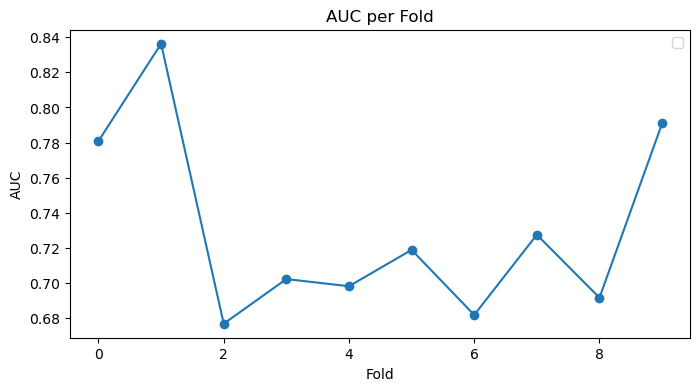

In [60]:
print(fold_aucs)
plt.figure(figsize=(8,4))

plt.plot(fold_aucs, marker="o")

plt.xlabel("Fold")
plt.ylabel("AUC")
plt.legend()
plt.title("AUC per Fold")

In [61]:
final_preds = np.nansum(oof_preds, axis=0)
y_true = y.values

Text(0.5, 1.0, 'Rolling Calibration (window=500)')

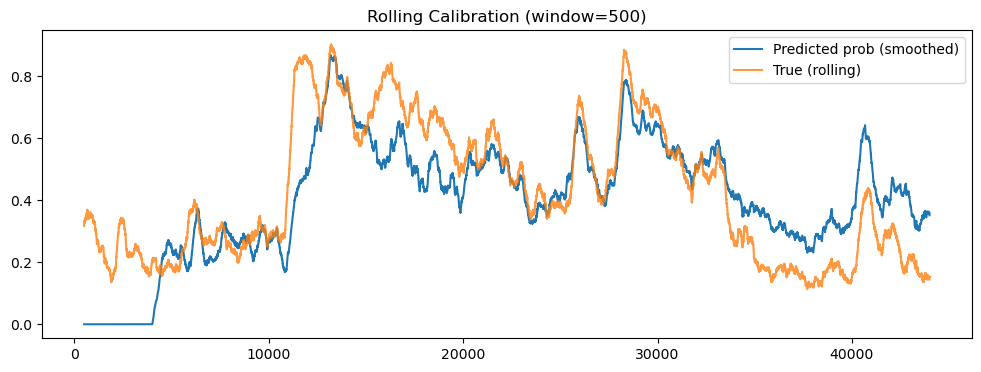

In [62]:
import matplotlib.pyplot as plt

window = 500

pred_smooth = pd.Series(final_preds).rolling(window).mean()
target_smooth = pd.Series(y_true).rolling(window).mean()

plt.figure(figsize=(12,4))
plt.plot(pred_smooth, label="Predicted prob (smoothed)")
plt.plot(target_smooth, label="True (rolling)", alpha=0.8)
plt.legend()
plt.title(f"Rolling Calibration (window={window})")

Text(0.5, 1.0, 'Prediction distribution')

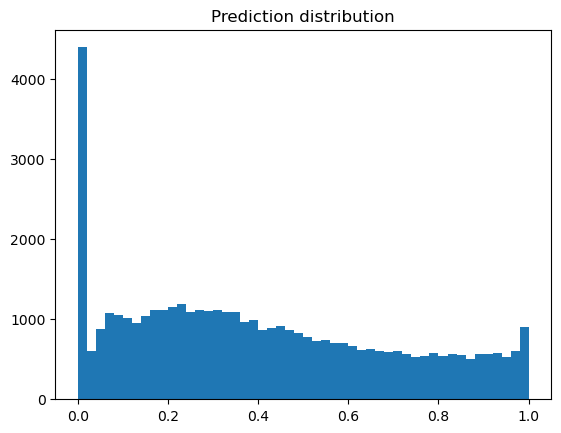

In [63]:
plt.hist(final_preds, bins=50)
plt.title("Prediction distribution")

In [64]:
import pandas as pd

avg_coefs = pd.Series(np.mean(fold_coefs, axis=0), index=features)
avg_coefs = avg_coefs.sort_values(key=abs, ascending=False)
pd.set_option("display.max_rows", None)
print(avg_coefs)

rel_spread_log1p                8.789626
microprice                      4.343039
microprice_weighted_10          4.262019
realized_vol_20_log1p           1.355781
trade_count_log1p               1.068757
vol_20_log1p                   -0.748538
total_ask_volume_10_log1p      -0.668628
max_trade_size_log1p            0.618803
std_trade_size_log1p           -0.589560
max_over_average_log1p         -0.520005
total_book_volume_log1p         0.450383
trade_count_change              0.441512
total_bid_volume_10_log1p      -0.419923
max_bid_ask_vol_ratio_log1p     0.397655
realized_vol_5_log1p            0.277413
avg_trade_size_log1p           -0.264856
lob_bids_volume_1_log1p        -0.249017
total_trade_volume_log1p        0.242498
buy_count_log1p                -0.212591
lob_depth_ratio_2              -0.159587
imbalance_depth_5              -0.140787
imbalance_depth_2               0.132826
min_trade_size_log1p           -0.130737
lob_depth_ratio_5               0.128831
imbalance_10    

In [65]:
sorted_tables = []

for i in range(len(fold_coefs)):
    s = pd.Series(fold_coefs[i], index=features)
    s = s.sort_values(key=abs, ascending=False)

    df_fold = pd.DataFrame({
        f"Fold_{i}_feature": s.index,
        f"Fold_{i}_coef": s.values
    })

    sorted_tables.append(df_fold.reset_index(drop=True))

In [66]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


coef_table = pd.concat(sorted_tables, axis=1)

print(coef_table)

                  Fold_0_feature  Fold_0_coef                Fold_1_feature  Fold_1_coef                Fold_2_feature  Fold_2_coef                Fold_3_feature   Fold_3_coef                Fold_4_feature  Fold_4_coef                Fold_5_feature  Fold_5_coef                Fold_6_feature  Fold_6_coef                Fold_7_feature  Fold_7_coef                Fold_8_feature  Fold_8_coef                Fold_9_feature  Fold_9_coef
0              trade_count_log1p     1.936244             trade_count_log1p     1.530114         realized_vol_20_log1p     1.665011         realized_vol_20_log1p  1.723296e+00              rel_spread_log1p    14.498647              rel_spread_log1p    17.595271              rel_spread_log1p    16.873566              rel_spread_log1p    15.582618              rel_spread_log1p    12.553218              rel_spread_log1p     9.821558
1           std_trade_size_log1p    -1.295669         realized_vol_20_log1p     1.441254             trade_count_log1p     1.461596 

In [67]:
from prettytable import PrettyTable

for i in range(len(sorted_tables)):
    df = sorted_tables[i].round(4)

    table = PrettyTable()
    table.field_names = ["feature", "coef"]

    for row in df.values:
        table.add_row(row)

    with open(f"C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\saved_info\\l1_fold\\fold_{i}.txt", "w") as f:
        f.write(str(table))

In [68]:
from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["feature", "avg_coef"]

for feature, coef in avg_coefs.round(4).items():
    table.add_row([feature, coef])

with open("C:\\Users\\jayod\\Documents\\Quant_Project\\microstructure-alpha-engine\\notebooks\\saved_info\\l1_fold\\avg.txt", "w") as f:
    f.write(str(table))